In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [3]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.shape

(4000, 28)

In [6]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [9]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [10]:
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

,0
Rainfall_mm,1.2
Soil_Moisture_pct,1.0
Yield_Tonnes_Ha,0.8
Farm_ID,0.0
Crop,0.0
District,0.0
Farm_Area_Hectares,0.0
Season,0.0
Avg_Temperature_C,0.0
Humidity_pct,0.0


In [11]:
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())
df['Yield_Tonnes_Ha'] = df['Yield_Tonnes_Ha'].fillna(df['Yield_Tonnes_Ha'].median())

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.drop_duplicates()

In [15]:
print("Seasons:", df['Season'].unique())
print("Crops:", df['Crop'].unique())
print("States:", df['State'].nunique())
print("Irrigation Methods:", df['Irrigation_Method'].unique())

Seasons: ['Kharif' 'Rabi' 'Zaid']
Crops: ['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
States: 8
Irrigation Methods: ['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [16]:
season_count = df['Season'].value_counts()

season_count

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


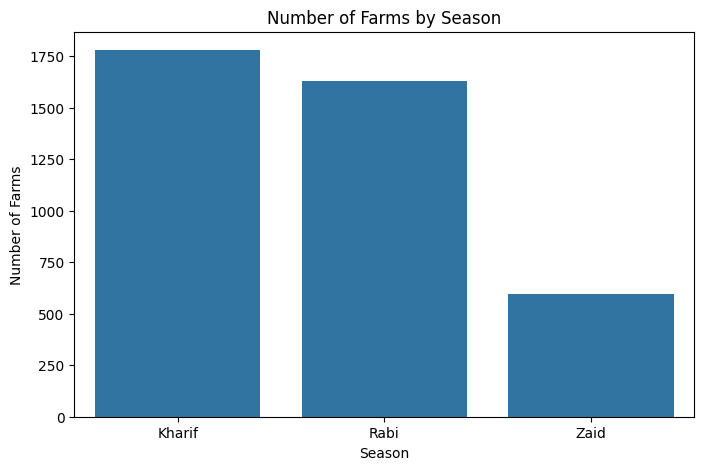

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

In [18]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


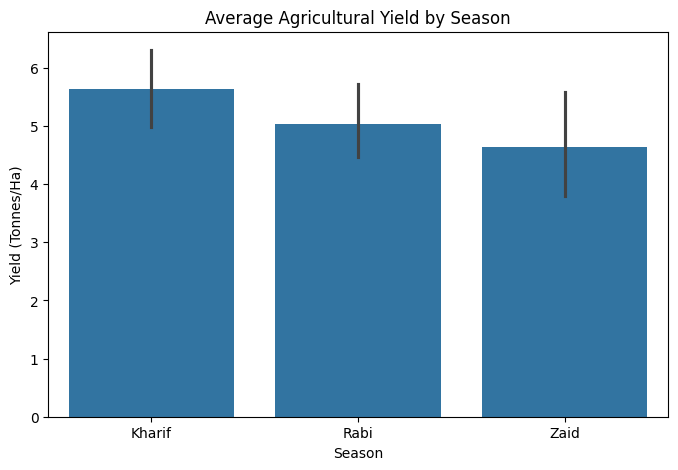

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [20]:
season_production = df.groupby('Season')['Production_Tonnes'].mean().sort_values(ascending=False)

season_production

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


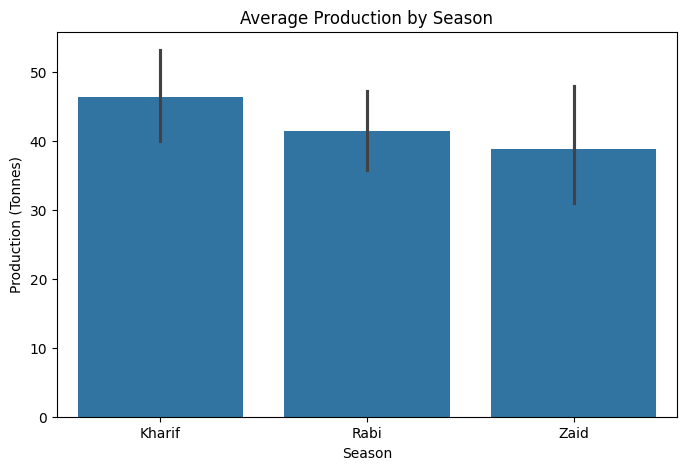

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes',
    estimator='mean'
)

plt.title('Average Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.show()

In [22]:
df.groupby('Season')['Rainfall_mm'].mean()

,Rainfall_mm
Season,
Kharif,849.199663
Rabi,437.615366
Zaid,304.654714


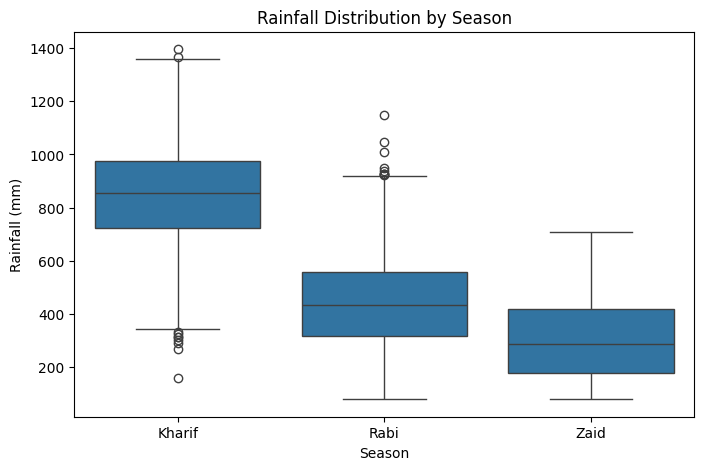

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Season', y='Rainfall_mm')

plt.title('Rainfall Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')

plt.show()

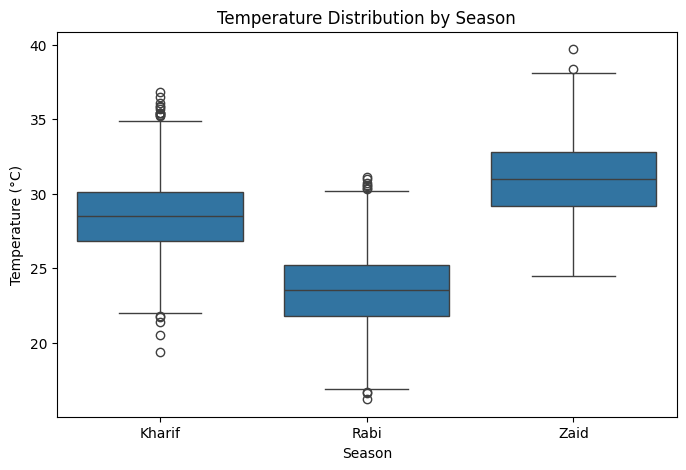

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Season', y='Avg_Temperature_C')

plt.title('Temperature Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')

plt.show()

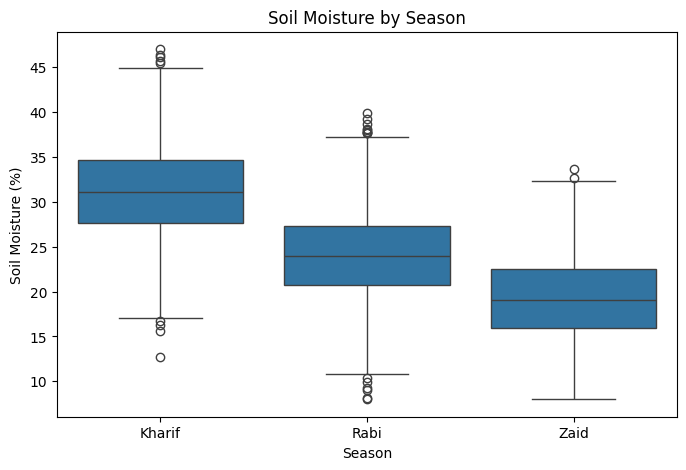

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='Season', y='Soil_Moisture_pct')

plt.title('Soil Moisture by Season')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')

plt.show()

In [26]:
crop_yield = df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

crop_yield


,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


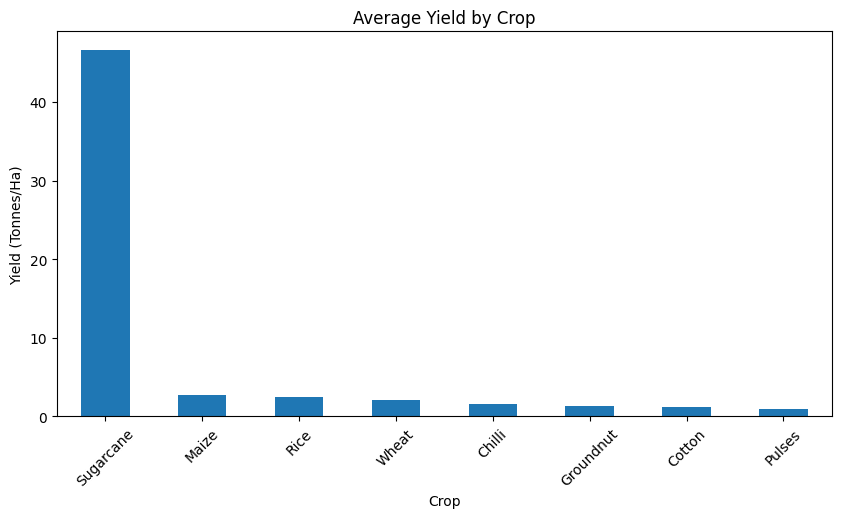

In [27]:
plt.figure(figsize=(10,5))

crop_yield.plot(kind='bar')

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=45)
plt.show()

In [28]:
crop_season = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


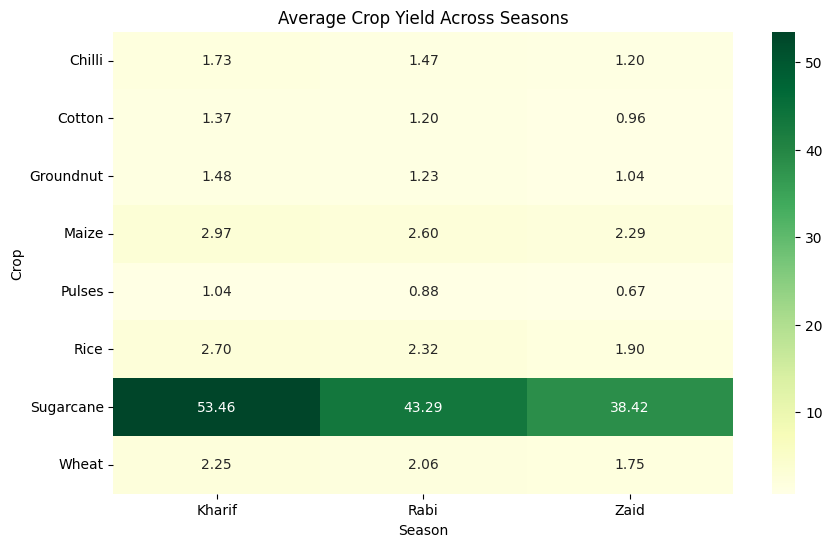

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    crop_season,
    annot=True,
    fmt='.2f',
    cmap='YlGn'
)

plt.title('Average Crop Yield Across Seasons')

plt.show()

In [30]:
irrigation_yield = df.groupby(
    'Irrigation_Method'
)['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

irrigation_yield

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


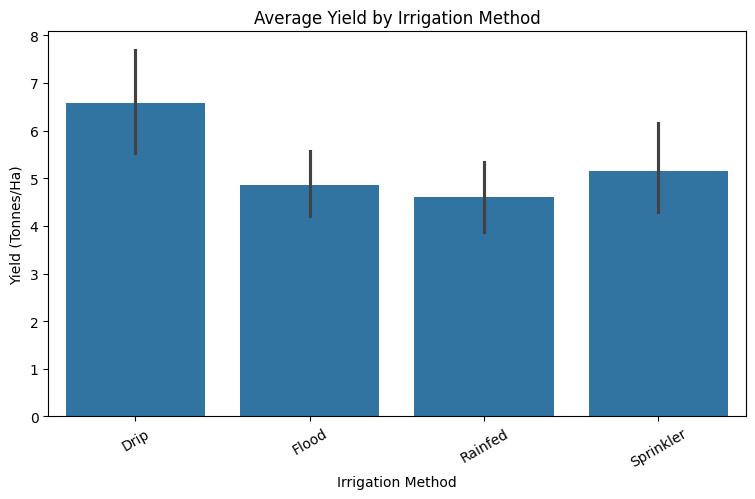

In [31]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=df,
    x='Irrigation_Method',
    y='Yield_Tonnes_Ha',
    estimator='mean'
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (Tonnes/Ha)')

plt.xticks(rotation=30)
plt.show()

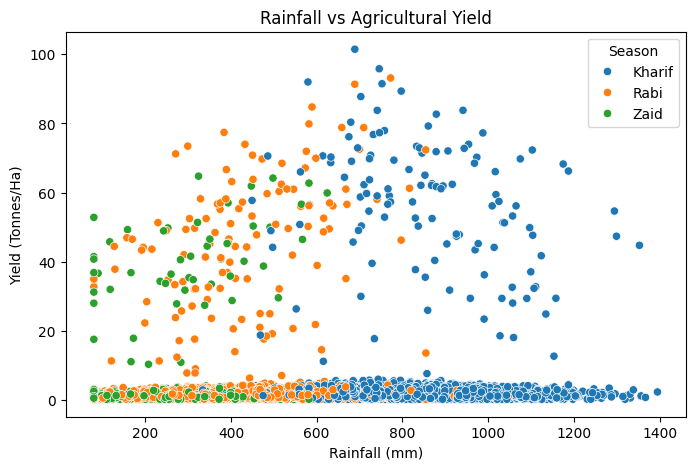

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

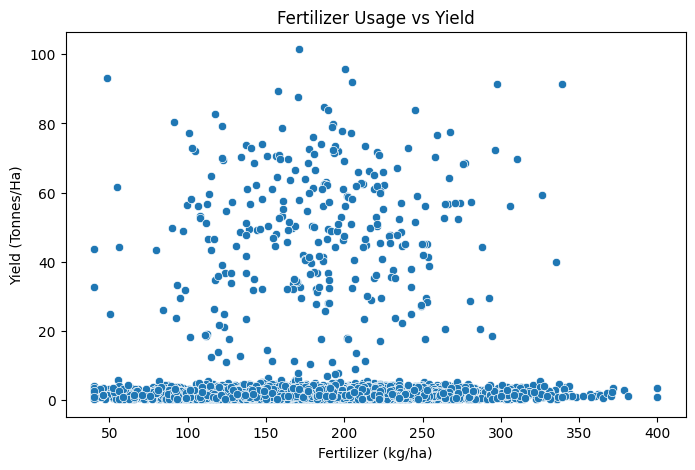

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha'
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [34]:
water_season = df.groupby(
    'Season'
)['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False)

water_season

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.891834
Rabi,5.186122
Zaid,4.413239


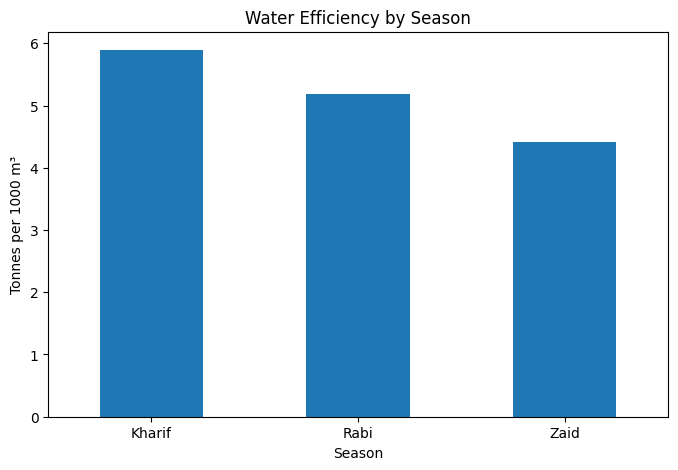

In [35]:
plt.figure(figsize=(8,5))

water_season.plot(kind='bar')

plt.title('Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Tonnes per 1000 m³')

plt.xticks(rotation=0)
plt.show()

In [36]:
economic = df.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].mean()

economic

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


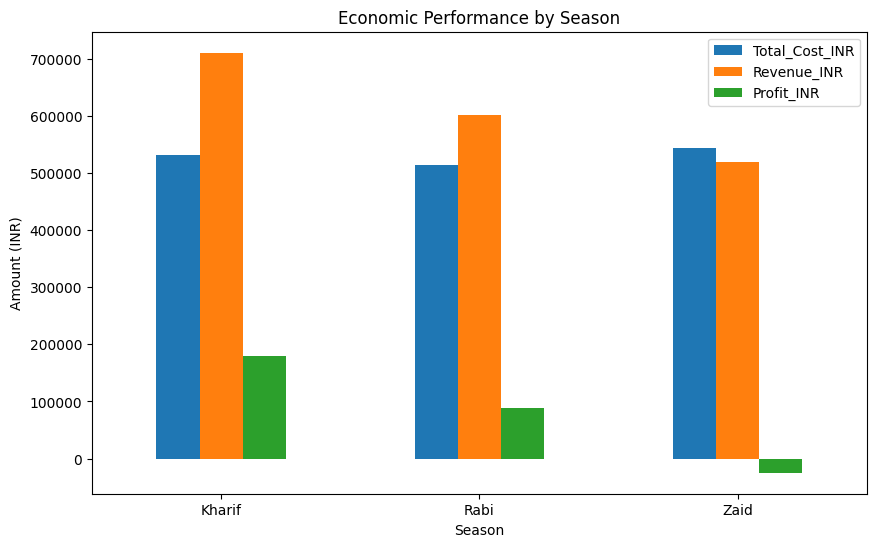

In [37]:
economic.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Economic Performance by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')

plt.xticks(rotation=0)
plt.show()

In [38]:
risk = df.groupby(
    'Season'
)['Disease_Pest_Risk_pct'].mean().sort_values(ascending=False)

risk

,Disease_Pest_Risk_pct
Season,
Kharif,54.467903
Rabi,40.482114
Zaid,38.216667


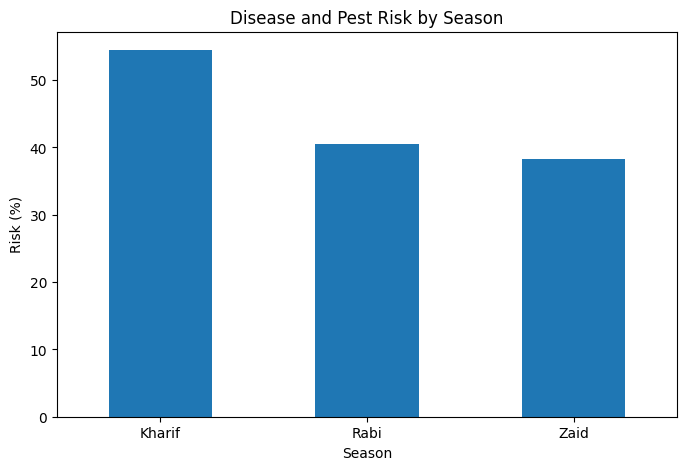

In [39]:
plt.figure(figsize=(8,5))

risk.plot(kind='bar')

plt.title('Disease and Pest Risk by Season')
plt.xlabel('Season')
plt.ylabel('Risk (%)')

plt.xticks(rotation=0)
plt.show()

In [40]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

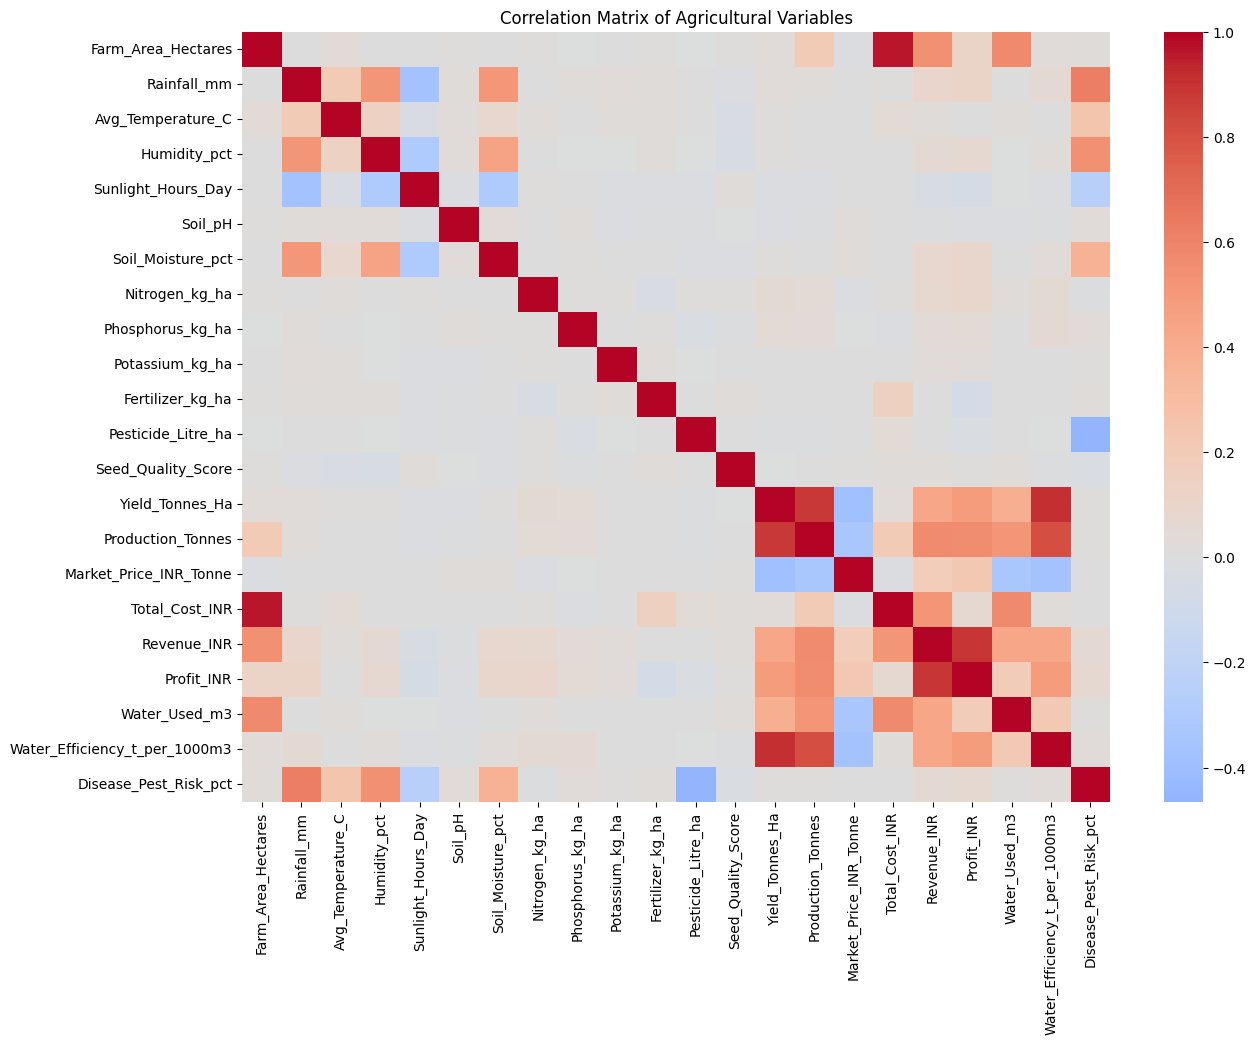

In [41]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

In [42]:
correlation['Yield_Tonnes_Ha'].sort_values(ascending=False)

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000000
Water_Efficiency_t_per_1000m3,0.912568
Production_Tonnes,0.882813
Profit_INR,0.488466
Revenue_INR,0.432152
Water_Used_m3,0.386294
Nitrogen_kg_ha,0.053149
Phosphorus_kg_ha,0.047941
Rainfall_mm,0.030951
Total_Cost_INR,0.030622


In [43]:
season_groups = [
    group['Yield_Tonnes_Ha'].values
    for _, group in df.groupby('Season')
]

anova = stats.f_oneway(*season_groups)

print("F-statistic:", anova.statistic)
print("P-value:", anova.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [44]:
season_groups = [
    group['Yield_Tonnes_Ha'].values
    for _, group in df.groupby('Season')
]

anova = stats.f_oneway(*season_groups)

print("F-statistic:", anova.statistic)
print("P-value:", anova.pvalue)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [45]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
}).round(2)

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm,Avg_Temperature_C,Soil_Moisture_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3,Total_Cost_INR,Revenue_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,,,
Kharif,5.63,46.31,849.20,28.45,31.15,6102.20,5.89,531804.41,710719.06,178914.65,54.47
Rabi,5.04,41.49,437.62,23.49,24.07,5846.99,5.19,513836.58,601526.05,87689.47,40.48
Zaid,4.64,38.89,304.65,31.04,19.28,6419.89,4.41,543976.73,519171.90,-24804.82,38.22


In [46]:
print("Best season for yield:",
      season_summary['Yield_Tonnes_Ha'].idxmax())

print("Best season for profit:",
      season_summary['Profit_INR'].idxmax())

print("Best season for water efficiency:",
      season_summary['Water_Efficiency_t_per_1000m3'].idxmax())

print("Highest risk season:",
      season_summary['Disease_Pest_Risk_pct'].idxmax())

Best season for yield: Kharif
Best season for profit: Kharif
Best season for water efficiency: Kharif
Highest risk season: Kharif
